[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/255ribeiro/curso_python_gis/blob/master/docs/geo_py/Teste_geopandas_ibge_censo_2022_v2.ipynb)




## Dados Geoespaciais com Geopandas


### Instalando o Ambiente
Para realizar as análises geoespaciais, alguns pacotes externos precisam ser instalados. Execute o código abaixo para instalar os pacotes necessários.

In [ ]:
!pip install geopandas shapely mapclassify libpysal splot esda pysal contextily
!pip install --upgrade pyshp
!pip install --upgrade descartes
!pip install --upgrade fiona

/bin/bash: line 1: python.exe: command not found
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.8/142.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.9/47.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.6/141.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.

### Sobre os dados

Baixados em [https://www.ibge.gov.br/estatisticas/downloads-estatisticas.html](https://www.ibge.gov.br/estatisticas/downloads-estatisticas.html)

Dicionário de dados para Agregados preliminares por setores censitários:

[https://view.officeapps.live.com/op/view.aspx?src=https%3A%2F%2Fftp.ibge.gov.br%2FCensos%2FCenso_Demografico_2022%2FAgregados_por_Setores_Censitarios_preliminares%2Farquivos_complementares%2FDicionario_de_dados_agregados_preliminares.xlsx&wdOrigin=BROWSELINK](https://view.officeapps.live.com/op/view.aspx?src=https%3A%2F%2Fftp.ibge.gov.br%2FCensos%2FCenso_Demografico_2022%2FAgregados_por_Setores_Censitarios_preliminares%2Farquivos_complementares%2FDicionario_de_dados_agregados_preliminares.xlsx&wdOrigin=BROWSELINK)



#### Dicionário de dados:

| **Nome da coluna** | **Tipo de dado** | **Tamanho** | **Descrição** |
| --- | --- | --- | --- |
| CD_SETOR | texto | 16 | Geocódigo de Setor Censitário |
| AREA_KM2 | real |  | Área do Setor Censitário em quilômetros quadrados |
| CD_REGIAO | numérico | 1 | Código das Grandes Regiões (Regiões Geográficas) |
| NM_REGIAO | texto | 15 | Nome das Grandes Regiões (Regiões Geográficas) |
| CD_UF | numérico | 2 | Código da Unidade da Federação |
| NM_UF | texto | 20 | Nome da Unidade da Federação |
| CD_MUN | numérico | 7 | Código do município |
| NM_MUN | texto | 50 | Nome do município |
| CD_DIST | numérico | 9 | Código do distrito |
| NM_DIST | texto | 50 | Nome do distrito |
| CD_SUBDIS | numérico | 11 | Código do subdistrito |
| NM_SUBDIST | texto | 50 | Nome do subdistrito |
| CD_MICRO | numérico | 5 | Código da microrregião |
| NM_MICRO | texto | 50 | Nome da microrregião |
| CD_MESO | numérico | 4 | Código da mesorregião |
| NM_MESO | texto | 50 | Nome da mesorregião |
| CD_RGI | numérico | 6 | Código da região geográfica imediata |
| NM_RGI | texto | 50 | Nome da região geográfica imediata |
| CD_RGINT | numérico | 4 | Código da região geográfica intermediária |
| NM_RGINT | texto | 50 | Nome da região geográfica intermediária |
| CD_CONCURB | numérico | 7 | Código da Concentração Urbana |
| NM_CONCURB | texto | 50 | Nome da Concentração Urbana |
| V0001 | numérico |  | Total de pessoas |
| V0002 | numérico |  | Total de Domicílios (DPPO + DPPV + DPPUO + DPIO + DCCM + DCSM) |
| V0003 | numérico |  | Total de Domicílios Particulares (DPPO + DPPV + DPPUO + DPIO) |
| V0004 | numérico |  | Total de Domicílios Coletivos (DCCM + DCSM) |
| V0005 | real |  | Média de moradores em Domicílios Particulares Ocupados (Total pessoas em Domicílios Particulares Ocupados / DPPO + DPIO) |
| V0006 | real |  | Percentual de Domicílios Particulares Ocupados Imputados (Total DPO imputados / Total DPO) |
| V0007 | numérico |  | Total de Domicílios Particulares Ocupados (DPPO + DPIO) |

### Importando pacotes

In [2]:
import pandas as pd
import numpy as np
import zipfile

# para gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# para a análise de dados espaciais
import geopandas as gp

import mapclassify as mc
import contextily as cx

### Baixando Arquivos

O código abaixo faz o download da malha geoespacial do IBGE para o Brasil com o agregado de dados preliminares do censo 2022 por setor censitário. Os setoes censitários são delimitações do espaço criados pelo IBGE. Para maiores informações sobre sentores censitários, acesse o link abaixo:
[https://metadados.snirh.gov.br/geonetwork/srv/api/records/cdb721a0-2d5d-45eb-9764-b831eb0b576e](https://metadados.snirh.gov.br/geonetwork/srv/api/records/cdb721a0-2d5d-45eb-9764-b831eb0b576e)

In [3]:
!wget https://255ribeiro.github.io/curso_python_gis/geo_py/BA_Malha_Preliminar_2022.zip


--2025-03-31 13:11:21--  https://255ribeiro.github.io/curso_python_gis/geo_py/BA_Malha_Preliminar_2022.zip
Resolving 255ribeiro.github.io (255ribeiro.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to 255ribeiro.github.io (255ribeiro.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 62263048 (59M) [application/zip]
Saving to: ‘BA_Malha_Preliminar_2022.zip’

BA_Malha_Preliminar 100%[===================>]  59.38M   130MB/s    in 0.5s    

2025-03-31 13:11:23 (130 MB/s) - ‘BA_Malha_Preliminar_2022.zip’ saved [62263048/62263048]



### Extraindo do arquivo zip

O código abaixo extrai o arquivo "BA_Malha_Preliminar_2022.json" do arquivo Zip baixado pelo código acima.

In [4]:
with zipfile.ZipFile("BA_Malha_Preliminar_2022.zip", 'r') as zip_ref:
  zip_ref.extractall("./BA_Malha_Preliminar_2022")

### Carregando GeoJson

Após a extração, é necessário carregar o arquivo BA_Malha_Preliminar_2022.json no notebook. Carregar arquivos com o geopandas é bem parecido com carregar um arquivo no pandas. No código abaixo o arquivo é carregado em um geodataframe (um objeto que combina uma tabela de dados com geometrias georreferenciadas) chamado df_geo.

In [5]:
df_geo = gp.read_file("./BA_Malha_Preliminar_2022/BA_Malha_Preliminar_2022.json")

### Informações do arquivo

Após o carregamento do arquivo, é importante explorar as caracteristicas do arquivo. Começando pela tabela de dados. A função shape mostra o número de linhas e colunas na tabela (linhas, colunas).

In [6]:
df_geo.shape

(30642, 30)

A função .info() mostra um pouco mais de informações. O número de linhas aparece como RangeIndex e o número de colunas como total xx Columns. Uma tabela de resumo dos dados émostrata abaixo também. na coluna **#** vemos os indices de cada coluna, **Column** mostra o nome das colunas, **Non-Null** count mostra a quantidade de linhas em que cada valor foi preenchido (em tabelas um campo pode não estar preenchido por nenhum valor, isso é chamado de um "Null" value)

In [7]:
df_geo.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 30642 entries, 0 to 30641
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   CD_SETOR    30642 non-null  object  
 1   AREA_KM2    30642 non-null  float64 
 2   CD_REGIAO   30642 non-null  object  
 3   NM_REGIAO   30642 non-null  object  
 4   CD_UF       30642 non-null  object  
 5   NM_UF       30642 non-null  object  
 6   CD_MUN      30642 non-null  object  
 7   NM_MUN      30642 non-null  object  
 8   CD_DIST     30642 non-null  object  
 9   NM_DIST     30642 non-null  object  
 10  CD_SUBDIST  30642 non-null  object  
 11  NM_SUBDIST  5491 non-null   object  
 12  CD_MICRO    30642 non-null  object  
 13  NM_MICRO    30642 non-null  object  
 14  CD_MESO     30642 non-null  object  
 15  NM_MESO     30642 non-null  object  
 16  CD_RGI      30642 non-null  object  
 17  NM_RGI      30642 non-null  object  
 18  CD_RGINT    30642 non-null  object  
 

In [8]:
df_geo.describe()

,AREA_KM2
count,30642.000000
mean,18.430926
std,54.460159
min,0.001235
25%,0.061144
50%,0.254225
75%,8.604529
max,1484.628804


In [9]:
df_geo.head()


,CD_SETOR,AREA_KM2,CD_REGIAO,NM_REGIAO,CD_UF,NM_UF,CD_MUN,NM_MUN,CD_DIST,NM_DIST,...,CD_CONCURB,NM_CONCURB,v0001,v0002,v0003,v0004,v0005,v0006,v0007,geometry
0,290010805000001P,1.252312,2,Nordeste,29,Bahia,2900108,Abaíra,290010805,Abaíra,...,None,None,807,421,419,2,2.668919,0.000000,296,"POLYGON ((-41.65404 -13.25992, -41.65423 -13.2..."
1,290010805000002P,0.258089,2,Nordeste,29,Bahia,2900108,Abaíra,290010805,Abaíra,...,None,None,416,234,234,0,2.461538,11.834320,169,"POLYGON ((-41.66355 -13.25025, -41.66425 -13.2..."
2,290010805000003P,0.636238,2,Nordeste,29,Bahia,2900108,Abaíra,290010805,Abaíra,...,None,None,681,392,392,0,2.522222,5.185185,270,"POLYGON ((-41.66645 -13.25044, -41.66702 -13.2..."
3,290010805000004P,1.395440,2,Nordeste,29,Bahia,2900108,Abaíra,290010805,Abaíra,...,None,None,626,344,344,0,2.608333,2.083333,240,"POLYGON ((-41.66355 -13.25025, -41.66345 -13.2..."
4,290010805000005P,1.130747,2,Nordeste,29,Bahia,2900108,Abaíra,290010805,Abaíra,...,None,None,276,159,159,0,2.732673,0.990099,101,"POLYGON ((-41.6511 -13.25848, -41.65082 -13.25..."


In [10]:
pd.set_option('display.max_columns', None)
df_geo.head()

,CD_SETOR,AREA_KM2,CD_REGIAO,NM_REGIAO,CD_UF,NM_UF,CD_MUN,NM_MUN,CD_DIST,NM_DIST,CD_SUBDIST,NM_SUBDIST,CD_MICRO,NM_MICRO,CD_MESO,NM_MESO,CD_RGI,NM_RGI,CD_RGINT,NM_RGINT,CD_CONCURB,NM_CONCURB,v0001,v0002,v0003,v0004,v0005,v0006,v0007,geometry
0,290010805000001P,1.252312,2,Nordeste,29,Bahia,2900108,Abaíra,290010805,Abaíra,29001080500,None,29023,Seabra,2906,Centro Sul Baiano,290013,Brumado,2904,Vitória da Conquista,None,None,807,421,419,2,2.668919,0.000000,296,"POLYGON ((-41.65404 -13.25992, -41.65423 -13.2..."
1,290010805000002P,0.258089,2,Nordeste,29,Bahia,2900108,Abaíra,290010805,Abaíra,29001080500,None,29023,Seabra,2906,Centro Sul Baiano,290013,Brumado,2904,Vitória da Conquista,None,None,416,234,234,0,2.461538,11.834320,169,"POLYGON ((-41.66355 -13.25025, -41.66425 -13.2..."
2,290010805000003P,0.636238,2,Nordeste,29,Bahia,2900108,Abaíra,290010805,Abaíra,29001080500,None,29023,Seabra,2906,Centro Sul Baiano,290013,Brumado,2904,Vitória da Conquista,None,None,681,392,392,0,2.522222,5.185185,270,"POLYGON ((-41.66645 -13.25044, -41.66702 -13.2..."
3,290010805000004P,1.395440,2,Nordeste,29,Bahia,2900108,Abaíra,290010805,Abaíra,29001080500,None,29023,Seabra,2906,Centro Sul Baiano,290013,Brumado,2904,Vitória da Conquista,None,None,626,344,344,0,2.608333,2.083333,240,"POLYGON ((-41.66355 -13.25025, -41.66345 -13.2..."
4,290010805000005P,1.130747,2,Nordeste,29,Bahia,2900108,Abaíra,290010805,Abaíra,29001080500,None,29023,Seabra,2906,Centro Sul Baiano,290013,Brumado,2904,Vitória da Conquista,None,None,276,159,159,0,2.732673,0.990099,101,"POLYGON ((-41.6511 -13.25848, -41.65082 -13.25..."


### Plotagem com o geopandas

[https://geopandas.org/en/stable/docs/user_guide/mapping.html](https://geopandas.org/en/stable/docs/user_guide/mapping.html)

Existem muitas opções de como plotar um mapa com o geopandas. A maneira mais simples é utilizando a função .plot()

<Axes: >

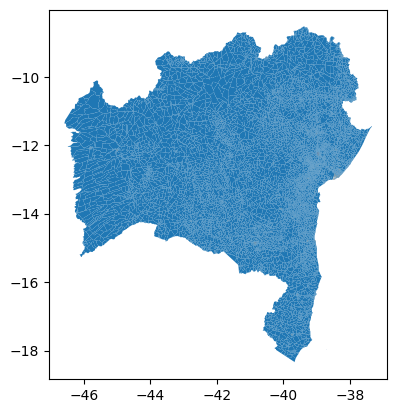

In [ ]:
df_geo.plot()

A opção de plotagem abaixo possibilita mais configurações e ajustes. É Possível configurar o tamanho da imagem figsize=(x,y), por exemplo. Mude os valores e veja o resultado.

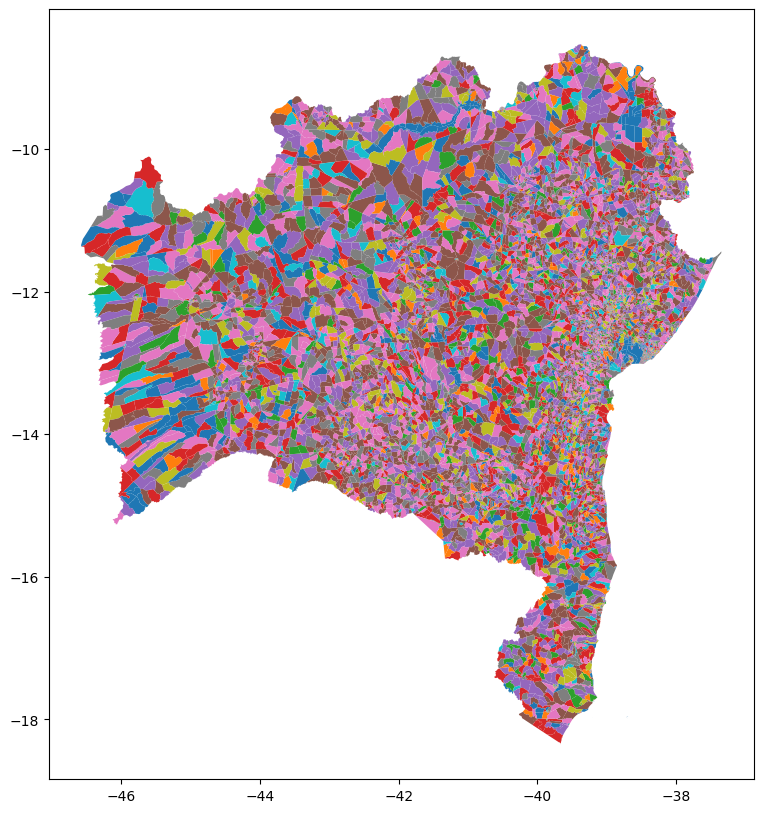

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
df_geo.plot(ax=ax, column = "v0001")
fig.show()

Também é possível plotar a malha sem preenchimento.

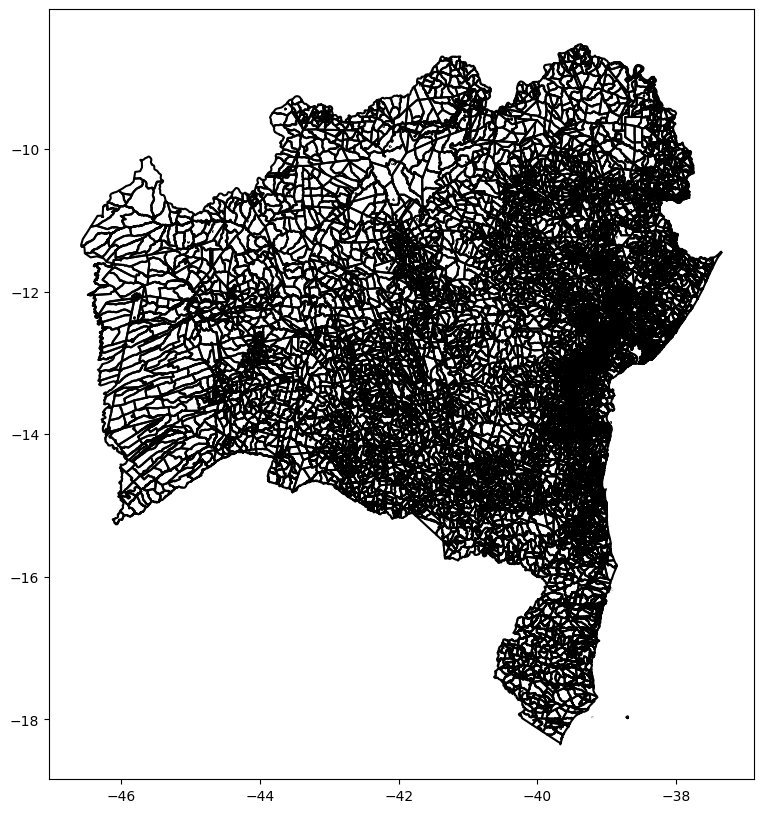

In [11]:
fig, ax = plt.subplots(figsize=(10,10))
df_geo.boundary.plot(ax=ax, edgecolor="black")
fig.show()

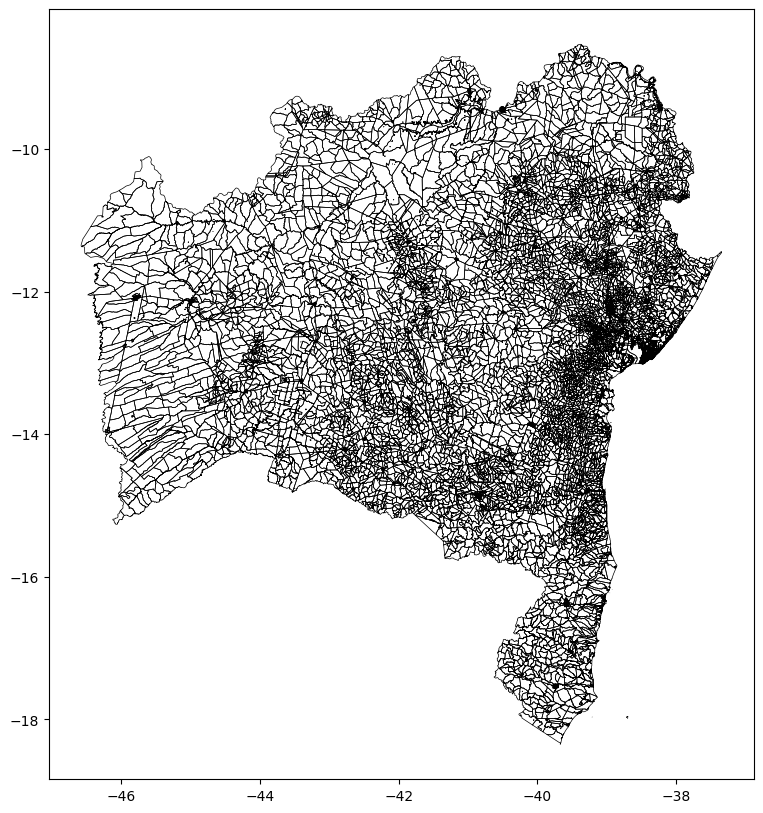

In [12]:
fig, ax = plt.subplots(figsize=(10,10))
df_geo.boundary.plot(ax=ax, edgecolor="brown", lw=.5)
fig.show()

### Tratando dados

In [13]:
df_geo["v0001"] = df_geo["v0001"].astype(int)
df_geo["v0002"] = df_geo["v0002"].astype(int)
df_geo["v0003"] = df_geo["v0003"].astype(int)
df_geo["v0004"] = df_geo["v0004"].astype(int)
df_geo["v0005"] = df_geo["v0005"].astype(float)
df_geo["v0006"] = df_geo["v0006"].astype(float)
df_geo["v0007"] = df_geo["v0007"].astype(int)


Criando novas colunas. A coluna de densidade populacional é criada pela divisão do número de pessoas em um setor censitáio pela área do próprio setor.

In [ ]:
# criado novas colunas
df_geo["densidade_pop"] =  df_geo["v0001"]/df_geo["AREA_KM2"]

Com a função .info() é possível ver o novo status do geodataframe

In [15]:
df_geo.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 30642 entries, 0 to 30641
Data columns (total 31 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   CD_SETOR       30642 non-null  object  
 1   AREA_KM2       30642 non-null  float64 
 2   CD_REGIAO      30642 non-null  object  
 3   NM_REGIAO      30642 non-null  object  
 4   CD_UF          30642 non-null  object  
 5   NM_UF          30642 non-null  object  
 6   CD_MUN         30642 non-null  object  
 7   NM_MUN         30642 non-null  object  
 8   CD_DIST        30642 non-null  object  
 9   NM_DIST        30642 non-null  object  
 10  CD_SUBDIST     30642 non-null  object  
 11  NM_SUBDIST     5491 non-null   object  
 12  CD_MICRO       30642 non-null  object  
 13  NM_MICRO       30642 non-null  object  
 14  CD_MESO        30642 non-null  object  
 15  NM_MESO        30642 non-null  object  
 16  CD_RGI         30642 non-null  object  
 17  NM_RGI         30642 no

A função .describe() apresenta novos cálculos estatísticos para as colunas do tipo float e int.

In [16]:
df_geo.describe()

,AREA_KM2,v0001,v0002,v0003,v0004,v0005,v0006,v0007,desnidade_pop
count,30642.000000,30642.000000,30642.000000,30642.000000,30642.000000,30642.000000,30642.000000,30642.000000,30642.000000
mean,18.430926,461.511194,224.417173,224.164447,0.252725,2.745468,2.032173,166.266497,6241.302646
std,54.460159,289.645276,131.152737,131.035016,1.539796,0.455014,3.254504,102.624350,10243.991791
min,0.001235,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.061144,248.000000,133.000000,133.000000,0.000000,2.571429,0.000000,90.000000,24.972272
50%,0.254225,440.000000,216.000000,216.000000,0.000000,2.760000,0.921659,160.000000,1692.239809
75%,8.604529,629.000000,298.000000,298.000000,0.000000,2.956522,3.225806,228.000000,8179.894673
max,1484.628804,4253.000000,2170.000000,2170.000000,102.000000,8.000000,100.000000,1397.000000,171696.149844


O parâmetro scheme pode gera o gráfico de densidade populacional em faixas. rode o comando abaixo, depois descomente a linha do parâmetro scheme e veja a diferença

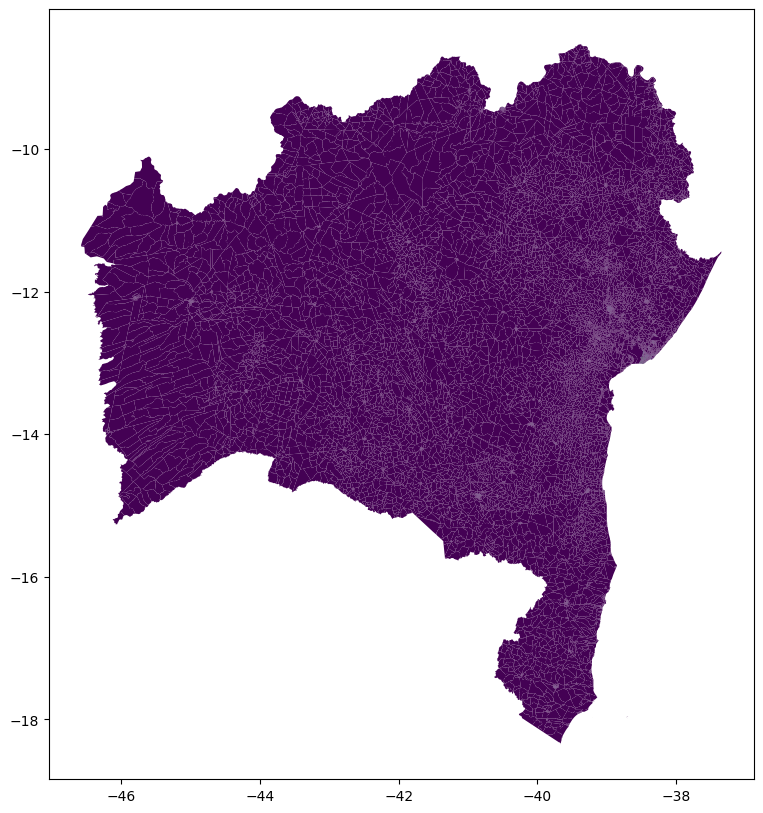

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))

df_geo.plot(ax=ax, column = "densidade_pop",
            #  scheme="quantiles",

            legend_kwds={"title": "Habitantes por km²"}
            )


### Mais sobre mapas e cores
color maps padrão
[https://matplotlib.org/stable/users/explain/colors/colormaps.html](https://matplotlib.org/stable/users/explain/colors/colormaps.html)

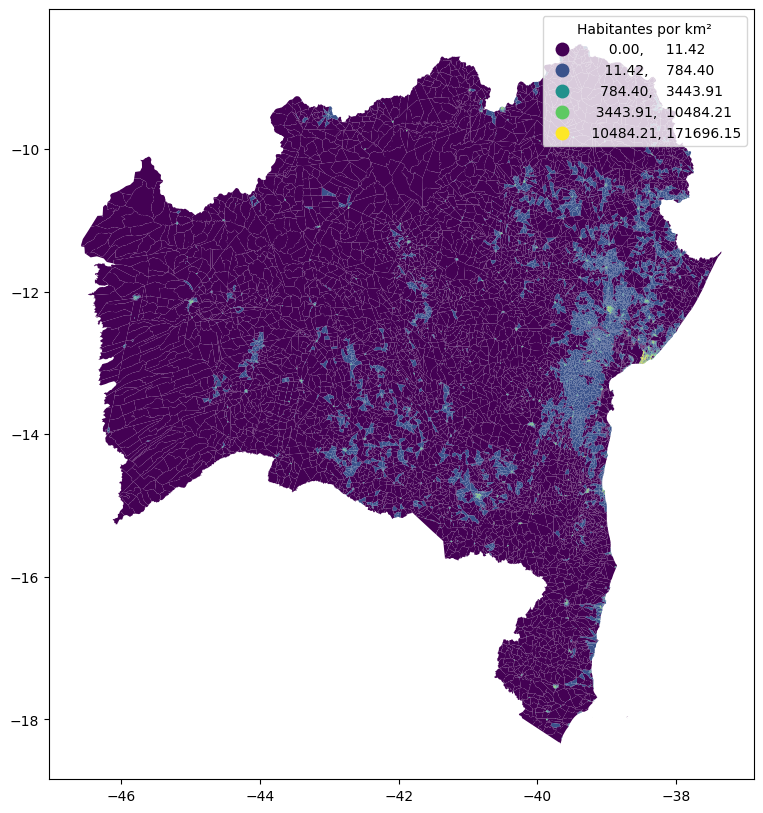

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))

df_geo.plot(ax=ax, column = "densidade_pop",
            scheme="quantiles",
            cmap='viridis',
            legend=True,
            legend_kwds={"title": "Habitantes por km²"}
            )


### Cmaps customizados
[https://matplotlib.org/stable/gallery/color/named_colors.html](https://matplotlib.org/stable/gallery/color/named_colors.html)



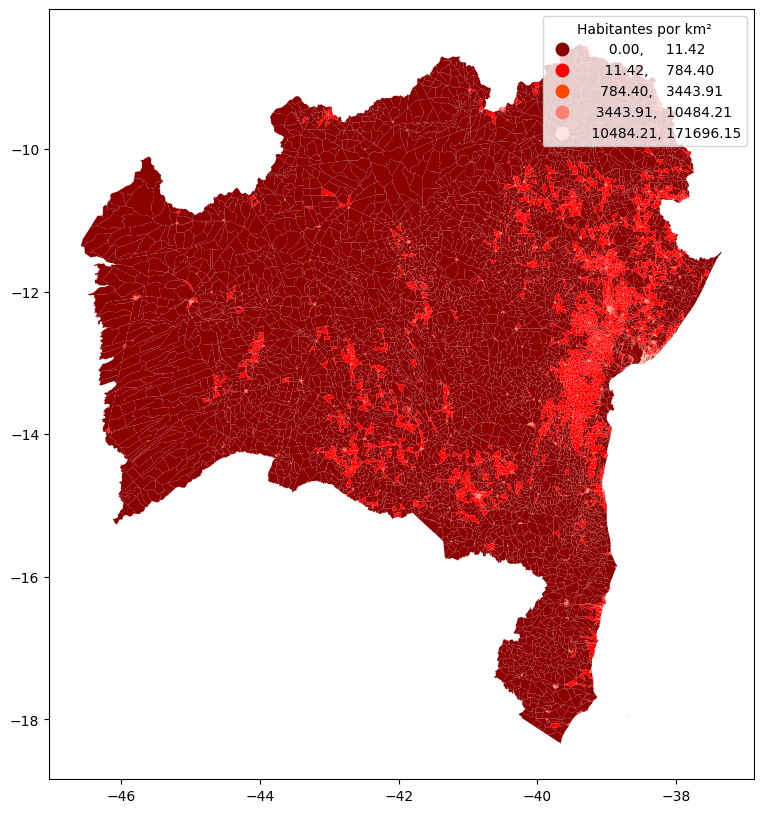

In [ ]:
from matplotlib import colors as mcolors

c_list = ["darkred","red","orangered", "salmon","mistyrose"]

c_map = mcolors.ListedColormap(c_list)

fig, ax = plt.subplots(figsize=(10,10))

df_geo.plot(ax=ax, column = "densidade_pop",
             scheme="quantiles",
             cmap=c_map,
             legend=True,
             legend_kwds={"title": "Habitantes por km²"}
             )


usando seletores de cores da web
[https://coolors.co/](https://coolors.co/)

['#271f30', '#6c5a49', '#c8ad55', '#9bc59d', '#d0fcb3']


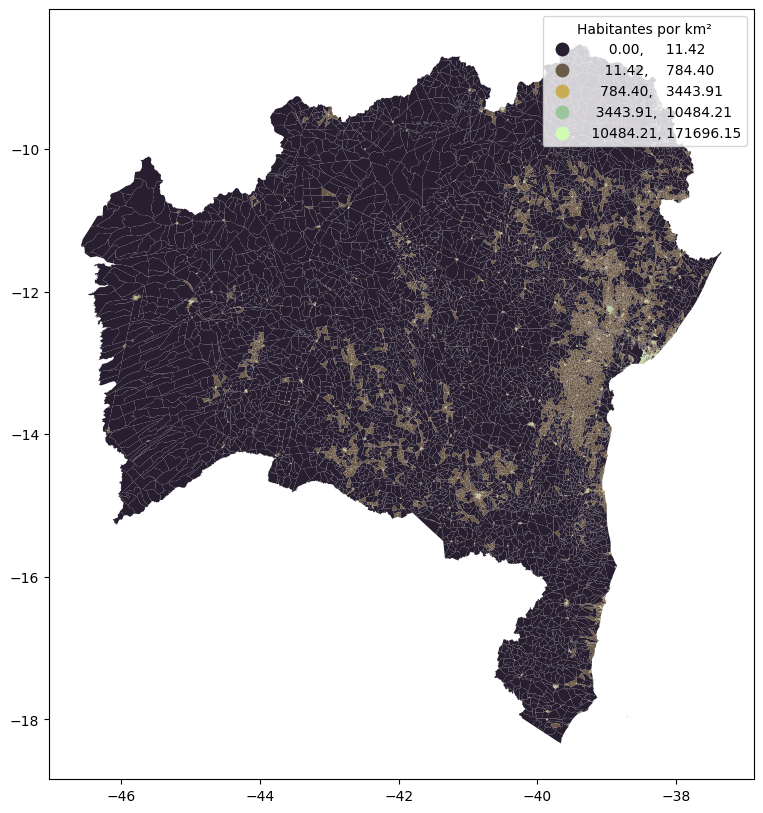

In [ ]:
c_list = ["#271f30","#6c5a49","#c8ad55","#9bc59d","#d0fcb3"]

print(c_list)

c_map = mcolors.ListedColormap(c_list)


fig, ax = plt.subplots(figsize=(10,10))

df_geo.plot(ax=ax, column = "densidade_pop",
             scheme="quantiles",
             cmap=c_map,
             legend=True,
             legend_kwds={"title": "Habitantes por km²"}
             )

### Filtrando mapa por valor de coluna

O código abaixo extrai (filtra) apenas as linhas que fazem parte do município de salvador e salva no geodataframe **df_geo_ssa**. Podemos ver também que o número de colunas permanece igual, mas o número de linhas é reduzido.

In [22]:
fltr = df_geo["NM_MUN"] == "Salvador"
df_geo_ssa = df_geo[fltr]
df_geo_ssa.shape, df_geo.shape

((4552, 31), (30642, 31))

In [23]:
df_geo_ssa.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 4552 entries, 20719 to 25270
Data columns (total 31 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   CD_SETOR       4552 non-null   object  
 1   AREA_KM2       4552 non-null   float64 
 2   CD_REGIAO      4552 non-null   object  
 3   NM_REGIAO      4552 non-null   object  
 4   CD_UF          4552 non-null   object  
 5   NM_UF          4552 non-null   object  
 6   CD_MUN         4552 non-null   object  
 7   NM_MUN         4552 non-null   object  
 8   CD_DIST        4552 non-null   object  
 9   NM_DIST        4552 non-null   object  
 10  CD_SUBDIST     4552 non-null   object  
 11  NM_SUBDIST     4552 non-null   object  
 12  CD_MICRO       4552 non-null   object  
 13  NM_MICRO       4552 non-null   object  
 14  CD_MESO        4552 non-null   object  
 15  NM_MESO        4552 non-null   object  
 16  CD_RGI         4552 non-null   object  
 17  NM_RGI         4552 non-n

<Axes: >

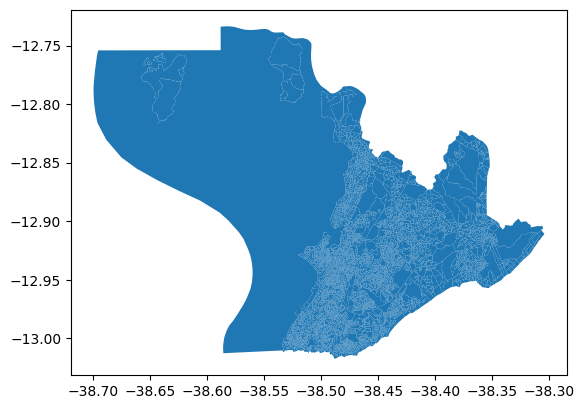

In [ ]:
df_geo_ssa.plot()

### Sistema de coordenadas

[https://www.earthdatascience.org/courses/earth-analytics/spatial-data-r/intro-to-coordinate-reference-systems/](https://www.earthdatascience.org/courses/earth-analytics/spatial-data-r/intro-to-coordinate-reference-systems/)

In [ ]:
df_geo_ssa.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
df_geo_ssa = df_geo_ssa.to_crs("31984")
df_geo_ssa.crs

<Projected CRS: EPSG:31984>
Name: SIRGAS 2000 / UTM zone 24S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Brazil - between 42°W and 36°W, northern and southern hemispheres, onshore and offshore.
- bounds: (-42.0, -26.35, -36.0, 0.74)
Coordinate Operation:
- name: UTM zone 24S
- method: Transverse Mercator
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

### Gravando Geojson

In [26]:
with open("SSA_BA_Malha_Preliminar_2022.json" , 'w') as file:
    file.write(df_geo_ssa.to_json())

### Abrindo GeoJson

In [27]:
df_2 = gp.read_file("SSA_BA_Malha_Preliminar_2022.json")
df_2.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 4552 entries, 0 to 4551
Data columns (total 32 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   id             4552 non-null   object  
 1   CD_SETOR       4552 non-null   object  
 2   AREA_KM2       4552 non-null   float64 
 3   CD_REGIAO      4552 non-null   object  
 4   NM_REGIAO      4552 non-null   object  
 5   CD_UF          4552 non-null   object  
 6   NM_UF          4552 non-null   object  
 7   CD_MUN         4552 non-null   object  
 8   NM_MUN         4552 non-null   object  
 9   CD_DIST        4552 non-null   object  
 10  NM_DIST        4552 non-null   object  
 11  CD_SUBDIST     4552 non-null   object  
 12  NM_SUBDIST     4552 non-null   object  
 13  CD_MICRO       4552 non-null   object  
 14  NM_MICRO       4552 non-null   object  
 15  CD_MESO        4552 non-null   object  
 16  NM_MESO        4552 non-null   object  
 17  CD_RGI         4552 non-n

<Axes: >

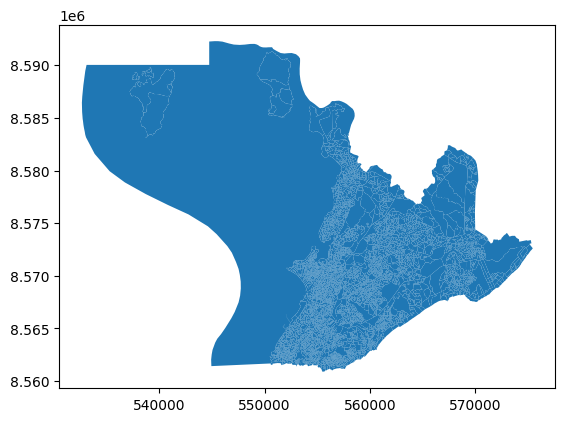

In [ ]:
df_2.plot()

### Eliminando feição indesejada

#### Identificando feição indesejada -método 1

In [ ]:
df_2['coords'] = df_2['geometry'].apply(lambda x: x.representative_point().coords[0])

In [ ]:
df_2['coords']

,coords
0,"(555517.6892997203, 8561162.794243902)"
1,"(555869.385196075, 8561221.765203156)"
2,"(555561.692228948, 8561448.0105288)"
3,"(555666.401386929, 8561893.694598991)"
4,"(555818.1373583635, 8561625.594414245)"
...,...
4547,"(554137.1694208445, 8563500.747517455)"
4548,"(551078.8695353717, 8562426.471542083)"
4549,"(551215.1880186847, 8562493.736728266)"
4550,"(552074.8722883032, 8564677.217530191)"


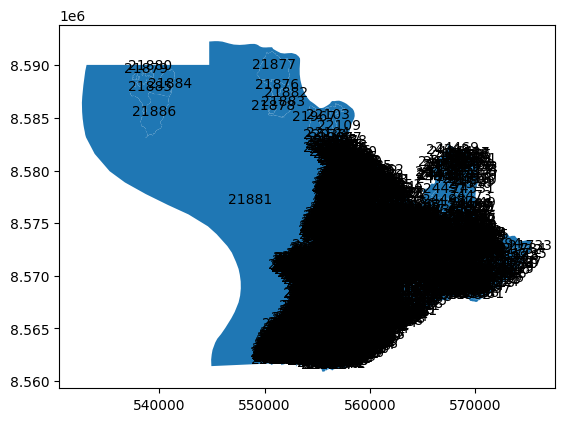

In [ ]:
df_2.plot()
for idx, row in df_2.iterrows():
    plt.annotate(text=row['id'], xy=row['coords'],
                 horizontalalignment='center')

#### Identificando feição indesejada - médodo 2

In [ ]:
df_2['AREA_KM2'].max()

386.114232

((1, 33), array(['21881'], dtype=object))

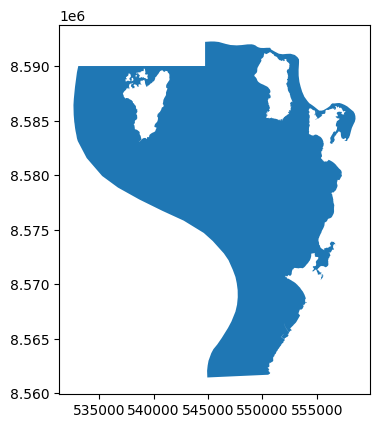

In [ ]:
fltr = df_2['AREA_KM2'] == df_2['AREA_KM2'].max()
df_2[fltr].plot()
df_2[fltr].shape, df_2[fltr]["id"].values

### Eliminado feição indesejada

In [28]:
fltr = df_2["id"] != "21881"
df_2 = df_2[fltr]

### Gerando mapa

<Axes: >

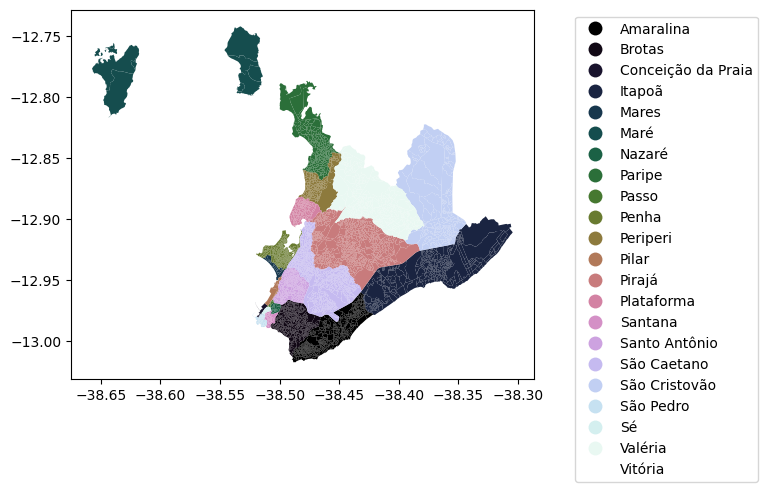

In [29]:
fig, ax = plt.subplots(1)
df_2.plot(ax = ax, column="NM_SUBDIST" ,cmap="cubehelix", legend=True, legend_kwds={'bbox_to_anchor': (1.5, 1)})


### Agregando com dissolve
[https://geopandas.org/en/stable/docs/user_guide/aggregation_with_dissolve.html](https://geopandas.org/en/stable/docs/user_guide/aggregation_with_dissolve.html)

In [ ]:
df_3 = df_2[['NM_SUBDIST', "v0001",'v0005', "geometry"]]
df_3 = df_3.dissolve(by='NM_SUBDIST', aggfunc='sum', as_index=False)

df_3.head()

,NM_SUBDIST,geometry,v0001,v0005
0,Amaralina,"POLYGON ((555768.884 8561020.182, 555765.446 8...",254133.0,1138.743352
1,Brotas,"POLYGON ((554383.205 8563533.513, 554358.146 8...",178577.0,900.154859
2,Conceição da Praia,"POLYGON ((552582.398 8565306.142, 552579.429 8...",416.0,4.270202
3,Itapoã,"POLYGON ((563322.057 8565454.801, 563258.583 8...",191205.0,805.219044
4,Mares,"POLYGON ((553634.123 8569419.347, 553605.637 8...",3314.0,37.887135


(array([535000., 540000., 545000., 550000., 555000., 560000., 565000.,
        570000., 575000., 580000.]),
 [Text(535000.0, 0, '535000'),
  Text(540000.0, 0, '540000'),
  Text(545000.0, 0, '545000'),
  Text(550000.0, 0, '550000'),
  Text(555000.0, 0, '555000'),
  Text(560000.0, 0, '560000'),
  Text(565000.0, 0, '565000'),
  Text(570000.0, 0, '570000'),
  Text(575000.0, 0, '575000'),
  Text(580000.0, 0, '580000')])

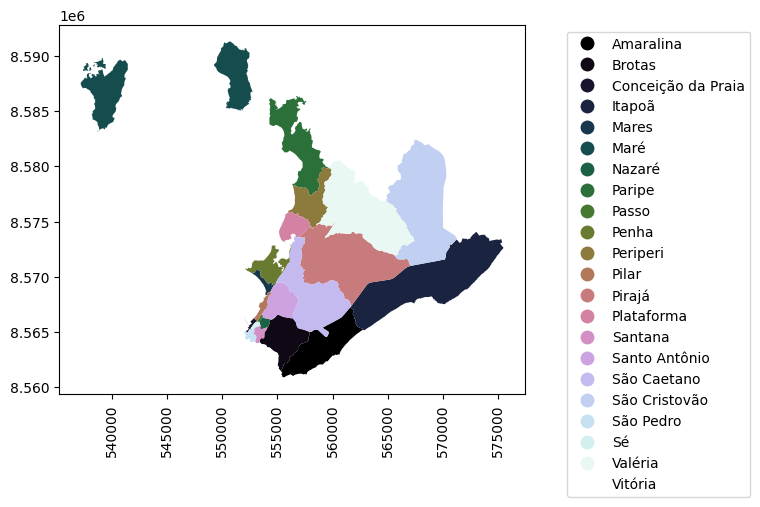

In [ ]:
fig, ax = plt.subplots(1)
df_3.plot(ax = ax,column="NM_SUBDIST", cmap="cubehelix", legend=True, legend_kwds={'bbox_to_anchor': (1.5, 1)})
plt.xticks(rotation=90)

### Colocando imagens de fundo

[https://geopandas.org/en/stable/gallery/plotting_basemap_background.html](https://geopandas.org/en/stable/gallery/plotting_basemap_background.html)

[https://contextily.readthedocs.io/en/latest/](https://contextily.readthedocs.io/en/latest/)

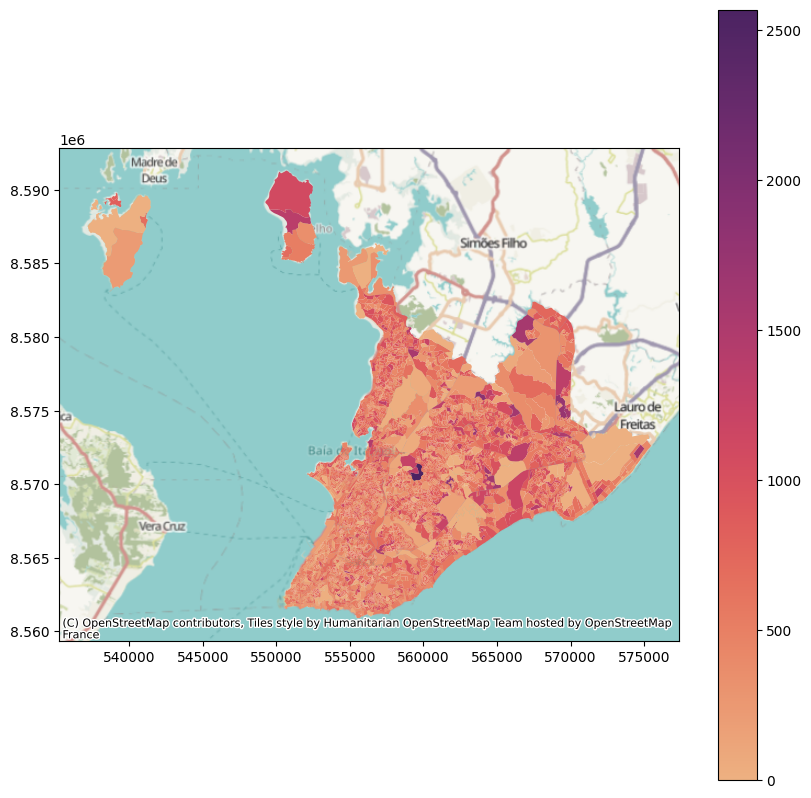

In [ ]:
fig, ax = plt.subplots(1, figsize=(10,10))
df_2.plot(ax = ax, column="v0001", cmap='flare',legend=True )
cx.add_basemap(ax=ax, crs=df_2.crs)

In [ ]:
# Listas de provedores de mapas online
cx.providers

{'OpenStreetMap': {'Mapnik': {'url': 'https://tile.openstreetmap.org/{z}/{x}/{y}.png',
   'max_zoom': 19,
   'html_attribution': '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors',
   'attribution': '(C) OpenStreetMap contributors',
   'name': 'OpenStreetMap.Mapnik'},
  'DE': {'url': 'https://tile.openstreetmap.de/{z}/{x}/{y}.png',
   'max_zoom': 18,
   'html_attribution': '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors',
   'attribution': '(C) OpenStreetMap contributors',
   'name': 'OpenStreetMap.DE'},
  'CH': {'url': 'https://tile.osm.ch/switzerland/{z}/{x}/{y}.png',
   'max_zoom': 18,
   'html_attribution': '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors',
   'attribution': '(C) OpenStreetMap contributors',
   'bounds': [[45, 5], [48, 11]],
   'name': 'OpenStreetMap.CH'},
  'France': {'url': 'https://{s}.tile.openstreetmap.fr/osmfr/{z}/{x}/{y}.png',
   'max_zoom': 20,
   'html_attribution': '&copy; OpenStreetMap France | &copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors',
   'attribution': '(C) OpenStreetMap France | (C) OpenStreetMap contributors',
   'name': 'OpenStreetMap.France'},
  'HOT': {'url': 'https://{s}.tile.openstreetmap.fr/hot/{z}/{x}/{y}.png',
   'max_zoom': 19,
   'html_attribution': '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors, Tiles style by <a href="https://www.hotosm.org/" target="_blank">Humanitarian OpenStreetMap Team</a> hosted by <a href="https://openstreetmap.fr/" target="_blank">OpenStreetMap France</a>',
   'attribution': '(C) OpenStreetMap contributors, Tiles style by Humanitarian OpenStreetMap Team hosted by OpenStreetMap France',
   'name': 'OpenStreetMap.HOT'},
  'BZH': {'url': 'https://tile.openstreetmap.bzh/br/{z}/{x}/{y}.png',
   'max_zoom': 19,
   'html_attribution': '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors, Tiles courtesy of <a href="http://www.openstreetmap.bzh/" target="_blank">Breton OpenStreetMap Team</a>',
   'attribution': '(C) OpenStreetMap contributors, Tiles courtesy of Breton OpenStreetMap Team',
   'bounds': [[46.2, -5.5], [50, 0.7]],
   'name': 'OpenStreetMap.BZH'},
  'CAT': {'url': 'https://tile.openstreetmap.bzh/ca/{z}/{x}/{y}.png',
   'max_zoom': 19,
   'html_attribution': '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors, Tiles courtesy of <a href="https://www.openstreetmap.cat" target="_blank">Breton OpenStreetMap Team</a>',
   'attribution': '(C) OpenStreetMap contributors, Tiles courtesy of Breton OpenStreetMap Team',
   'name': 'OpenStreetMap.CAT'}},
 'MapTilesAPI': {'OSMEnglish': {'url': 'https://maptiles.p.rapidapi.com/{variant}/{z}/{x}/{y}.png?rapidapi-key={apikey}',
   'html_attribution': '&copy; <a href="http://www.maptilesapi.com/">MapTiles API</a>, &copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors',
   'attribution': '(C) MapTiles API, (C) OpenStreetMap contributors',
   'variant': 'en/map/v1',
   'apikey': '<insert your api key here>',
   'max_zoom': 19,
   'name': 'MapTilesAPI.OSMEnglish'},
  'OSMFrancais': {'url': 'https://maptiles.p.rapidapi.com/{variant}/{z}/{x}/{y}.png?rapidapi-key={apikey}',
   'html_attribution': '&copy; <a href="http://www.maptilesapi.com/">MapTiles API</a>, &copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors',
   'attribution': '(C) MapTiles API, (C) OpenStreetMap contributors',
   'variant': 'fr/map/v1',
   'apikey': '<insert your api key here>',
   'max_zoom': 19,
   'name': 'MapTilesAPI.OSMFrancais'},
  'OSMEspagnol': {'url': 'https://maptiles.p.rapidapi.com/{variant}/{z}/{x}/{y}.png?rapidapi-key={apikey}',
   'html_attribution': '&copy; <a href="http://www.maptilesapi.com/">MapTiles API</a>, &copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contribut

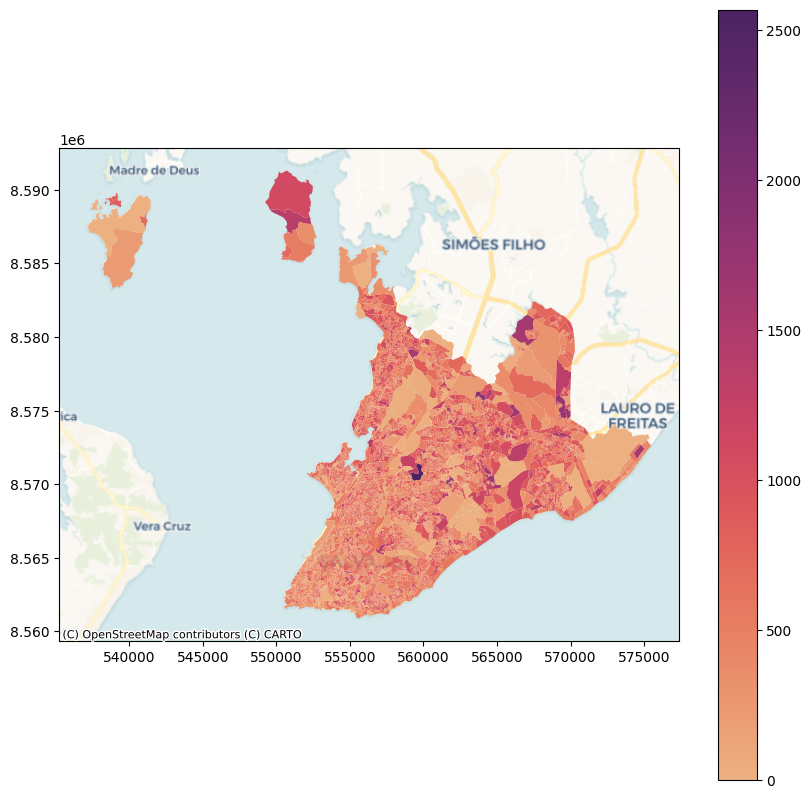

In [ ]:
fig, ax = plt.subplots(1, figsize=(10,10))
df_2.plot(ax = ax, column="densidade_pop", cmap='flare',legend=True )
cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Voyager ,  crs=df_2.crs)

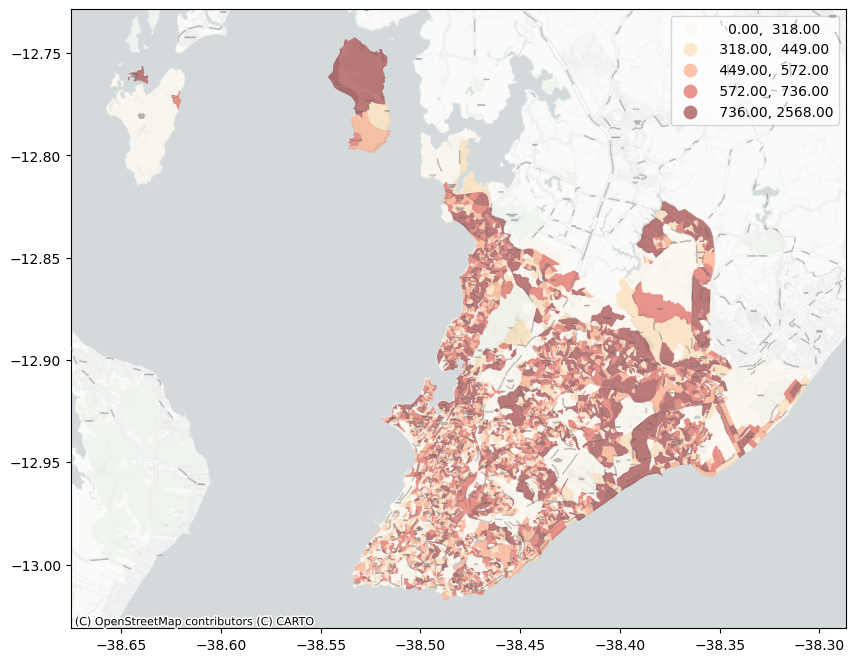

In [ ]:
alpha = .5
fig, ax = plt.subplots(1, figsize=(10,10))
df_2.plot(ax = ax, column="densidade_pop",
          cmap='OrRd',
          scheme = "quantiles",
          legend=True,
          alpha=alpha,

          )
cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels, zoom=12, crs=df_2.crs)
cx.add_basemap(ax, source=cx.providers.CartoDB.PositronOnlyLabels, zoom=15, crs=df_2.crs)

### Marcando um ponto por corrdenadas

#### Abra o Google Earth

[https://earth.google.com/web/](https://earth.google.com/web/)

Marque um ponto de localização do seu terreno

In [ ]:
from shapely.geometry import Point
# substitua os valores de latitue e longitude pelos valores do seu ponto
# use pontos para separar os decimais
lat = -12.9493280
lon = -38.3561944
pt_terreno = Point(lon, lat)

aplicando sistema de coordenads

In [ ]:
loc_terreno= gp.GeoDataFrame([1], geometry=[pt_terreno], crs="EPSG:4326")

In [ ]:
loc_terreno.head()

,0,geometry
0,1,POINT (-38.35619 -12.94933)


In [ ]:
loc_terreno = loc_terreno.to_crs(df_2.crs)

(array([535000., 540000., 545000., 550000., 555000., 560000., 565000.,
        570000., 575000., 580000.]),
 [Text(535000.0, 0, '535000'),
  Text(540000.0, 0, '540000'),
  Text(545000.0, 0, '545000'),
  Text(550000.0, 0, '550000'),
  Text(555000.0, 0, '555000'),
  Text(560000.0, 0, '560000'),
  Text(565000.0, 0, '565000'),
  Text(570000.0, 0, '570000'),
  Text(575000.0, 0, '575000'),
  Text(580000.0, 0, '580000')])

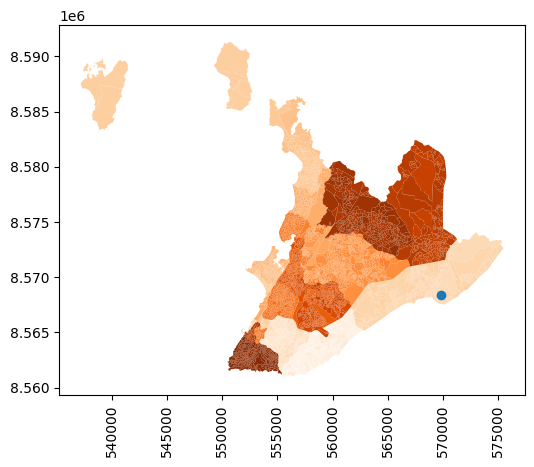

In [ ]:
fig, ax = plt.subplots()

df_2.plot(ax=ax, column= 'densidade_pop', cmap="Oranges")
loc_terreno.plot(ax=ax)
plt.xticks(rotation=90)

In [ ]:
entorno = loc_terreno.buffer(1000)

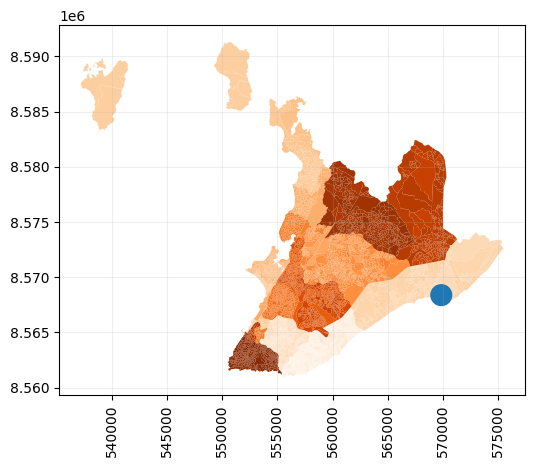

In [ ]:
fig, ax = plt.subplots()
plt.grid(alpha = .2) # monstra grid no gráfico
df_2.plot(ax=ax, columns= 'densidade_pop' cmap="Oranges")
entorno.plot(ax=ax)

plt.xticks(rotation=90)
fig.show()

### Intersects e Overlaps
[https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoSeries.intersects.html](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoSeries.intersects.html)
[https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoSeries.overlaps.html](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoSeries.overlaps.html)

In [ ]:
fltr = df_2.intersects(entorno[0])
df_4 = df_2[fltr]

/usr/local/lib/python3.11/dist-packages/matplotlib/text.py:1475: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(x))
/usr/local/lib/python3.11/dist-packages/matplotlib/text.py:1477: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(y))


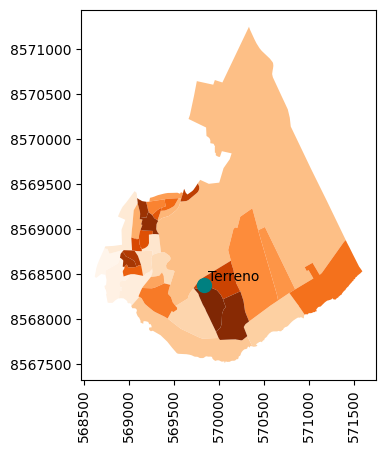

In [ ]:
fig, ax = plt.subplots()
fig.suptitle("Entorno do Terreno", fontsize=20)
df_4.plot(ax=ax,column= "densidade_pop" cmap="Oranges")
loc_terreno.plot(ax=ax, marker='o', color='teal', markersize=100)
ax.annotate("Terreno", xy= (loc_terreno.geometry.x, loc_terreno.geometry.y), xytext=(3, 3), textcoords="offset points") # escreve o nome do terreno
plt.xticks(rotation=90)
ax.ticklabel_format(style='plain') # remove notação científica
#salvando figura
fig.savefig('./entorno.svg')
fig.show()